PODUCT_ASOS_PROJECT

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('products_asos.csv', on_bad_lines='skip')


In [ ]:
df.head()

,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [ ]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

print(f'Data Loaded:{len(df)} rows')

Data Loaded:18378 rows


In [ ]:
# Analysis of the product_asos

# 1.how much money they are loosing
df['description'] = df['description'].astype(str)

def get_brand(text):
  if 'by' in text:
    try:
      return text.split('by')[1].split()
    except:
      return 'Unkwown'
  else:
    return 'Unknown'

df['brand_raw'] = df['description'].apply(get_brand)

In [ ]:
brand_map = {
    'New': 'New Look',
    'River': 'River Island',
    'Miss': 'Miss Selfridge',
    'TopshopWelcome': 'Topshop'
}

# Fix unhashable list values before mapping
df['brand_raw'] = df['brand_raw'].apply(lambda x: x[0] if isinstance(x, list) else x)

df['Brand'] = df['brand_raw'].map(brand_map).fillna(df['brand_raw'])

brand_counts = df['Brand'].value_counts()
valid_brands = brand_counts[brand_counts > 5].index
df_clean = df[df['Brand'].isin(valid_brands)].copy()

# Fixed: .head() must come before print()
print(df_clean['Brand'].value_counts().head())

Brand
ASOS              4844
Topshop           1017
New Look           511
River Island       474
Miss Selfridge     429
Name: count, dtype: int64


In [ ]:
df.columns

Index(['url', 'name', 'size', 'category', 'price', 'color', 'sku',
       'description', 'images', 'brand_raw', 'Brand'],
      dtype='object')

In [ ]:
# 2. Analyse the stock check out

def calculate_phantom_revenue(size_str):
    if not isinstance(size_str, str):
        return 0, 0.0

    # split: uk 6, uk 8, out of stock list
    sizes = size_str.split(',')
    total_sizes = len(sizes)

    # out of stock count
    out_of_stock_count = sum(1 for s in sizes if 'Out of stock' in s)

    # calculate rate (0.0 to 1.0)
    rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0

    return out_of_stock_count, rate

# Fix: call the function with (x), not just reference it
metrics = df_clean['size'].apply(lambda x: calculate_phantom_revenue(x))

df_clean['stockout_count'] = [x[0] for x in metrics]
df_clean['stockout_rate'] = [x[1] for x in metrics]

df_clean['lost_revenue'] = df_clean['price'] * df_clean['stockout_count']

cols = ['Brand', 'name', 'price', 'stockout_count', 'lost_revenue']
print(df_clean.sort_values(by='lost_revenue', ascending=False).head(5)[cols])

         Brand                                               name  price  \
2941   Barbour               Barbour Beadnell wax jacket in black  219.0   
21948  Topshop  Topshop premium real leather collared zip thro...  260.0   
2715      ASOS  ASOS DESIGN premium real leather trench coat i...  220.0   
15584     ASOS  ASOS EDITION geo embellished fringe plunge mid...  250.0   
29838  Topshop           Topshop Baggy co-ord jeans in green cord   50.0   

       stockout_count  lost_revenue  
2941                9        1971.0  
21948               7        1820.0  
2715                7        1540.0  
15584               6        1500.0  
29838              27        1350.0  


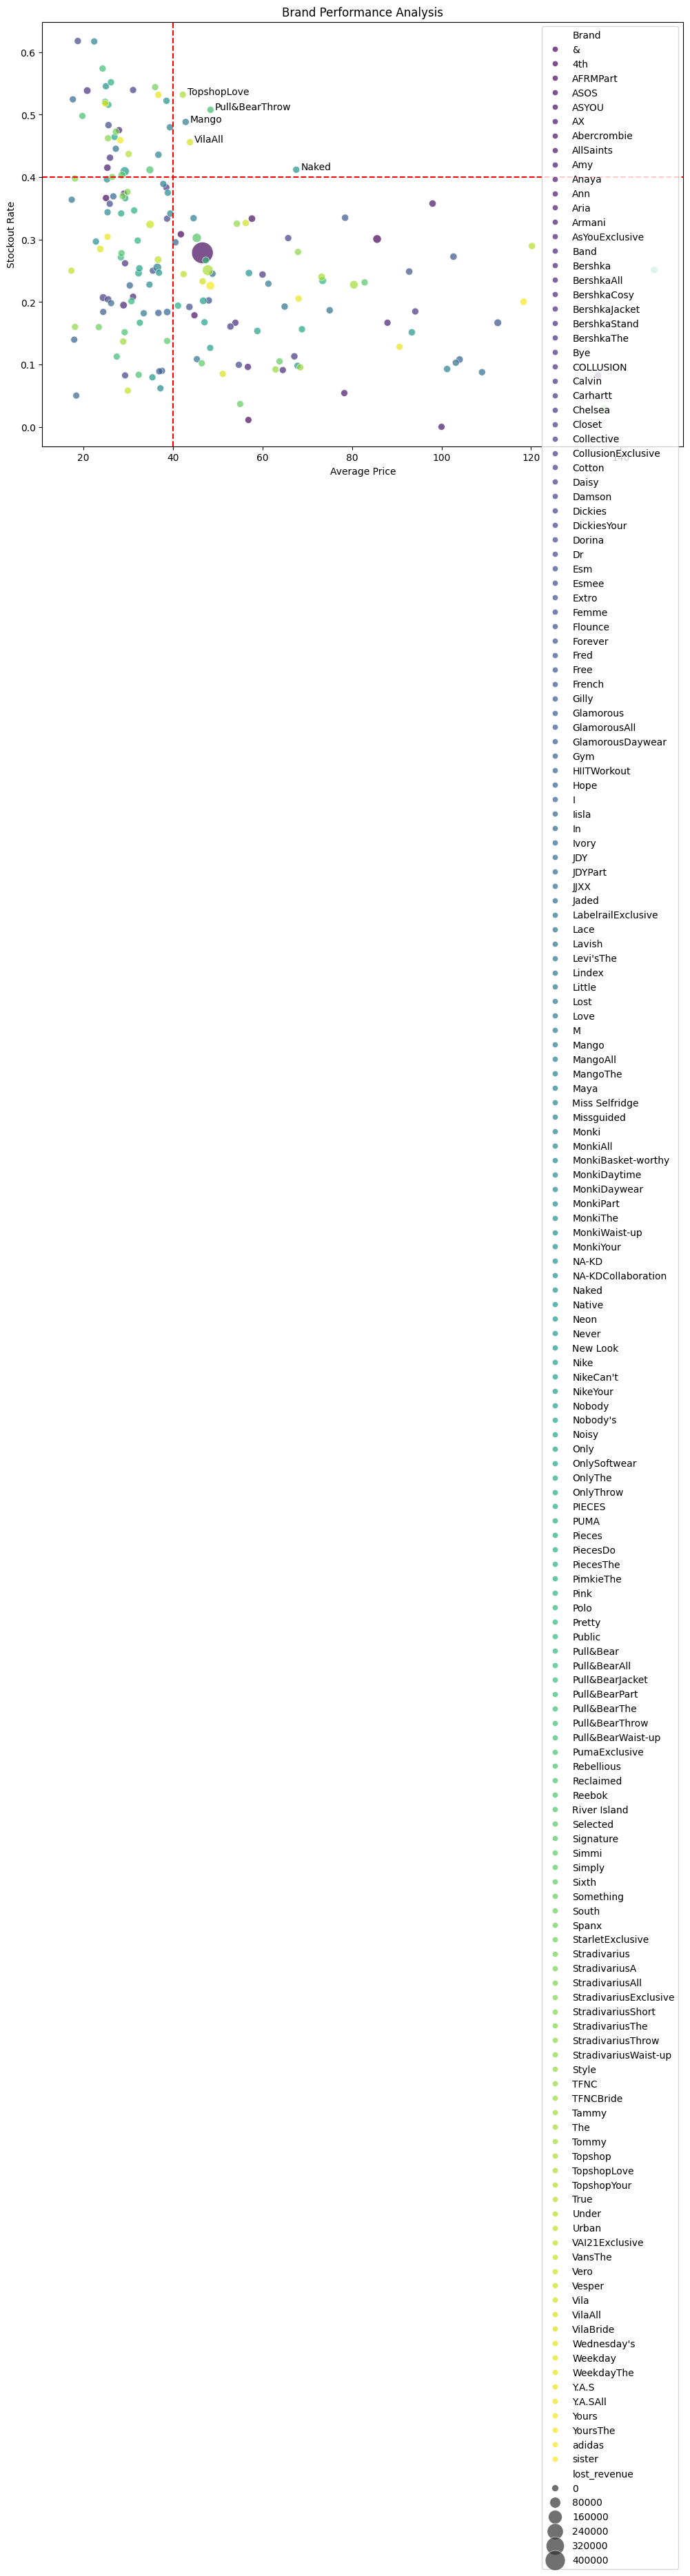

In [ ]:
brand_strategy = df_clean.groupby('Brand').agg(
    price=('price', 'mean'),
    stockout_count=('stockout_count', 'mean'),
    stockout_rate=('stockout_rate', 'mean'),   # was missing
    lost_revenue=('lost_revenue', 'sum'),
    name=('name', 'count')
).reset_index()

brand_strategy = brand_strategy[brand_strategy['name'] > 10]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=brand_strategy,
    x='price',
    y='stockout_rate',
    size='lost_revenue',
    sizes=(50, 500),
    alpha=0.7,
    palette='viridis',
    hue='Brand'              # palette requires hue
)

# Fix: column filter syntax was wrong
winners = brand_strategy[
    (brand_strategy['price'] > 40) &
    (brand_strategy['stockout_rate'] > 0.4)
]

# Fix: was using iloc[1] instead of iloc[i]
for i in range(len(winners)):
    plt.text(
        winners.iloc[i]['price'] + 1,
        winners.iloc[i]['stockout_rate'],
        winners.iloc[i]['Brand']
    )

plt.title('Brand Performance Analysis')
plt.xlabel('Average Price')
plt.ylabel('Stockout Rate')
plt.axvline(x=40, color='red', linestyle='--')
plt.axhline(y=0.4, color='red', linestyle='--')   # axline -> axhline
plt.show()

END